# Revised National Parks Analysis
## Using Simpler, More Interpretable Measures

**Three Approaches:**
1. **Neighbor Count** (RECOMMENDED) - Count parks within radius of each park
2. **Grid-Based** - Divide US into equal-sized grids
3. **Metro Areas** (OPTIONAL) - Parks near major cities

## Setup & Imports

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
import warnings
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)



## Helper Functions

In [56]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    Returns distance in miles with 1.4x road multiplier
    """
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    # Radius of earth in miles
    r = 3956
    
    # Apply 1.4x multiplier for road distance
    return c * r * 1.4



## Load Your Data

**IMPORTANT:** Update this cell with your actual data loading code!

Required columns:
- `Park Name` (or similar)
- `Region`
- `Total Recreation Visits` (or similar)
- `Latitude`
- `Longitude`

In [57]:
# ============================================
# LOAD YOUR DATA HERE
# ============================================

# Option A: If you have a single merged CSV
parks_df = pd.read_csv('/Users/rebeccayedid/Desktop/SI CLASSES/SI 699/mini project/total_visitation')

# Option B: If you need to merge two datasets
# visits_df = pd.read_csv('park_visits.csv')
# coords_df = pd.read_csv('park_coordinates.csv')
# parks_df = visits_df.merge(coords_df, on='Park Name', how='inner')

parks_df = parks_df.drop(columns=['Unnamed: 0'])

# ============================================
# Verify data loaded correctly
# ============================================
print(f"Loaded {len(parks_df)} parks")
print(f"\nColumns: {list(parks_df.columns)}")
print(f"\nFirst few rows:")
parks_df.head()


Loaded 63 parks

Columns: ['ParkName', 'clean_name', 'Region', 'Latitude', 'Longitude', 'RecreationVisits']

First few rows:


,ParkName,clean_name,Region,Latitude,Longitude,RecreationVisits
0,Acadia NP,acadia,Northeast,44.35,-68.21,134113188
1,Arches NP,arches,Intermountain,38.68,-109.57,39675085
2,Badlands NP,badlands,Midwest,43.75,-102.50,45958032
3,Big Bend NP,big bend,Intermountain,29.25,-103.25,14476096
4,Biscayne NP,biscayne,Southeast,25.65,-80.08,20815641


## Data Validation

In [58]:
# Check for missing values
print("Missing values:")
print(parks_df.isnull().sum())

# Basic statistics
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)
print(f"\nTotal parks: {len(parks_df)}")
print(f"Total visits across all parks: {parks_df['RecreationVisits'].sum():,.0f}")
print(f"Average visits per park: {parks_df['RecreationVisits'].mean():,.0f}")
print(f"Median visits per park: {parks_df['RecreationVisits'].median():,.0f}")
print(f"\nRegions: {parks_df['Region'].unique()}")
print(f"\nParks per region:")
print(parks_df['Region'].value_counts())

Missing values:
ParkName            0
clean_name          0
Region              0
Latitude            0
Longitude           0
RecreationVisits    0
dtype: int64

BASIC STATISTICS

Total parks: 63
Total visits across all parks: 3,210,182,909
Average visits per park: 50,955,284
Median visits per park: 27,639,533

Regions: <StringArray>
['Northeast', 'Intermountain', 'Midwest', 'Southeast', 'Pacific West',
 'Alaska']
Length: 6, dtype: str

Parks per region:
Region
Intermountain    19
Pacific West     17
Midwest           9
Alaska            8
Southeast         7
Northeast         3
Name: count, dtype: int64


---
# APPROACH 1: NEIGHBOR COUNT ANALYSIS


For each park, count how many other parks are within a specified radius.

"Do parks with more nearby neighbors receive more visits?"

## Calculate Neighbor Counts

In [59]:
# Set the radius (try 200, 300, or 500 miles)
RADIUS_MILES = 300

print(f"Calculating neighbor counts within {RADIUS_MILES} miles...\n")

results = []

for idx1, park1 in parks_df.iterrows():
    neighbor_count = 0
    neighbor_names = []
    neighbor_distances = []
    
    for idx2, park2 in parks_df.iterrows():
        if idx1 != idx2:  # Don't count the park itself
            distance = haversine(
                park1['Longitude'], park1['Latitude'],
                park2['Longitude'], park2['Latitude']
            )
            
            if distance <= RADIUS_MILES:
                neighbor_count += 1
                neighbor_names.append(park2['ParkName'])
                neighbor_distances.append(distance)
    
    results.append({
        'Park Name': park1['ParkName'],
        'Region': park1['Region'],
        'Total Visits': park1['RecreationVisits'],
        'Neighbor Count': neighbor_count,
        'Latitude': park1['Latitude'],
        'Longitude': park1['Longitude'],
        'Closest 3 Neighbors': ', '.join(neighbor_names[:3]) + ('...' if len(neighbor_names) > 3 else ''),
        'Avg Distance to Neighbors': np.mean(neighbor_distances) if neighbor_distances else np.nan
    })

neighbor_df = pd.DataFrame(results)

print(f"✓ Calculated neighbor counts for {len(neighbor_df)} parks")
neighbor_df.head(10)

Calculating neighbor counts within 300 miles...

✓ Calculated neighbor counts for 63 parks


,Park Name,Region,Total Visits,Neighbor Count,Latitude,Longitude,Closest 3 Neighbors,Avg Distance to Neighbors
0,Acadia NP,Northeast,134113188,0,44.35,-68.21,,NaN
1,Arches NP,Intermountain,39675085,6,38.68,-109.57,"Black Canyon of the Gunnison NP, Bryce Canyon ...",168.789545
2,Badlands NP,Midwest,45958032,1,43.75,-102.50,Wind Cave NP,70.706139
3,Big Bend NP,Intermountain,14476096,2,29.25,-103.25,"Carlsbad Caverns NP, Guadalupe Mountains NP",295.119704
4,Biscayne NP,Southeast,20815641,2,25.65,-80.08,"Dry Tortugas NP, Everglades NP",172.014701
5,Black Canyon of the Gunnison NP,Intermountain,10973033,6,38.57,-107.72,"Arches NP, Canyonlands NP, Capitol Reef NP...",191.109115
6,Bryce Canyon NP,Intermountain,54254911,7,37.57,-112.18,"Arches NP, Canyonlands NP, Capitol Reef NP...",174.343191
7,Canyonlands NP,Intermountain,18491617,7,38.20,-109.93,"Arches NP, Black Canyon of the Gunnison NP, Br...",167.277512
8,Capitol Reef NP,Intermountain,29963941,8,38.20,-111.17,"Arches NP, Black Canyon of the Gunnison NP, Br...",181.191540
9,Carlsbad Caverns NP,Intermountain,24320852,3,32.17,-104.44,"Big Bend NP, Guadalupe Mountains NP, White San...",164.899561


## Summary Statistics

In [60]:
print("="*70)
print(f"NEIGHBOR COUNT ANALYSIS (within {RADIUS_MILES} miles)")
print("="*70)

print(f"\n SUMMARY STATISTICS:")
print(f"   Average neighbor count: {neighbor_df['Neighbor Count'].mean():.2f}")
print(f"   Median neighbor count: {neighbor_df['Neighbor Count'].median():.0f}")
print(f"   Min neighbor count: {neighbor_df['Neighbor Count'].min():.0f}")
print(f"   Max neighbor count: {neighbor_df['Neighbor Count'].max():.0f}")
print(f"\n   Parks with 0 neighbors (isolated): {(neighbor_df['Neighbor Count'] == 0).sum()}")
print(f"   Parks with 1-2 neighbors: {((neighbor_df['Neighbor Count'] >= 1) & (neighbor_df['Neighbor Count'] <= 2)).sum()}")
print(f"   Parks with 3-5 neighbors: {((neighbor_df['Neighbor Count'] >= 3) & (neighbor_df['Neighbor Count'] <= 5)).sum()}")
print(f"   Parks with 6+ neighbors: {(neighbor_df['Neighbor Count'] >= 6).sum()}")

NEIGHBOR COUNT ANALYSIS (within 300 miles)

 SUMMARY STATISTICS:
   Average neighbor count: 2.38
   Median neighbor count: 2
   Min neighbor count: 0
   Max neighbor count: 8

   Parks with 0 neighbors (isolated): 11
   Parks with 1-2 neighbors: 30
   Parks with 3-5 neighbors: 15
   Parks with 6+ neighbors: 7


## Correlation

In [61]:
# Calculate correlation
correlation = neighbor_df['Neighbor Count'].corr(neighbor_df['Total Visits'])

print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)
print(f"\nCorrelation coefficient (r): {correlation:.3f}")

# Interpretation
if correlation > 0.5:
    print("\n STRONG POSITIVE correlation")
    print("  → Parks with more neighbors DO receive substantially more visits")
    print("  → This SUPPORTS your hypothesis")
elif correlation > 0.3:
    print("\n MODERATE POSITIVE correlation")
    print("  → Parks with more neighbors tend to receive more visits")
    print("  → This provides SOME SUPPORT for your hypothesis")
elif correlation > 0.1:
    print("\n WEAK POSITIVE correlation")
    print("  → Slight tendency for parks with more neighbors to receive more visits")
    print("  → This provides LIMITED SUPPORT for your hypothesis")
elif correlation > -0.1:
    print("\n NO CLEAR correlation")
    print("  → Neighbor count does not predict visitation")
    print("  → This DOES NOT SUPPORT your hypothesis")
else:
    print("\n NEGATIVE correlation")
    print("  → Parks with MORE neighbors actually receive FEWER visits")
    print("  → This is CONTRARY to your hypothesis")



CORRELATION ANALYSIS

Correlation coefficient (r): 0.020

 NO CLEAR correlation
  → Neighbor count does not predict visitation
  → This DOES NOT SUPPORT your hypothesis


## Examples: Most Clustered vs Most Isolated Parks

In [62]:
print("\n" + "="*70)
print("EXAMPLES: MOST CLUSTERED PARKS")
print("="*70)
print("\nTop 5 parks by neighbor count:")
most_clustered = neighbor_df.nlargest(5, 'Neighbor Count')[[
    'Park Name', 'Region', 'Neighbor Count', 'Total Visits', 'Closest 3 Neighbors'
]]
print(most_clustered.to_string(index=False))

print("\n" + "="*70)
print("EXAMPLES: MOST ISOLATED PARKS")
print("="*70)
isolated = neighbor_df[neighbor_df['Neighbor Count'] == 0][[
    'Park Name', 'Region', 'Total Visits'
]]
if len(isolated) > 0:
    print(f"\nParks with 0 neighbors (completely isolated):")
    print(isolated.to_string(index=False))
else:
    print("\nNo completely isolated parks found.")
    print("\nParks with fewest neighbors:")
    least_clustered = neighbor_df.nsmallest(5, 'Neighbor Count')[[
        'Park Name', 'Region', 'Neighbor Count', 'Total Visits'
    ]]
    print(least_clustered.to_string(index=False))


EXAMPLES: MOST CLUSTERED PARKS

Top 5 parks by neighbor count:
      Park Name        Region  Neighbor Count  Total Visits                                                 Closest 3 Neighbors
Capitol Reef NP Intermountain               8      29963941      Arches NP, Black Canyon of the Gunnison NP, Bryce Canyon NP...
Bryce Canyon NP Intermountain               7      54254911                       Arches NP, Canyonlands NP, Capitol Reef NP...
 Canyonlands NP Intermountain               7      18491617      Arches NP, Black Canyon of the Gunnison NP, Bryce Canyon NP...
  Mesa Verde NP Intermountain               7      25517152      Arches NP, Black Canyon of the Gunnison NP, Bryce Canyon NP...
      Arches NP Intermountain               6      39675085 Black Canyon of the Gunnison NP, Bryce Canyon NP, Canyonlands NP...

EXAMPLES: MOST ISOLATED PARKS

Parks with 0 neighbors (completely isolated):
                      Park Name        Region  Total Visits
                      Acadia N

## Regional Breakdown

In [63]:
print("\n" + "="*70)
print("REGIONAL BREAKDOWN")
print("="*70)

regional_summary = neighbor_df.groupby('Region').agg({
    'Park Name': 'count',
    'Neighbor Count': 'mean',
    'Total Visits': 'mean'
}).round(2)

regional_summary.columns = ['Number of Parks', 'Avg Neighbors', 'Avg Visits']
regional_summary = regional_summary.sort_values('Avg Neighbors', ascending=False)

print("\n", regional_summary)


REGIONAL BREAKDOWN

                Number of Parks  Avg Neighbors   Avg Visits
Region                                                    
Intermountain               19           3.84  58840256.16
Pacific West                17           2.88  43878372.65
Southeast                    7           1.57  84474976.71
Alaska                       8           1.25   6023741.62
Northeast                    3           1.00  81317122.33
Midwest                      9           0.44  51424396.67


## Visualizations


✓ Saved: neighbor_count_analysis.png


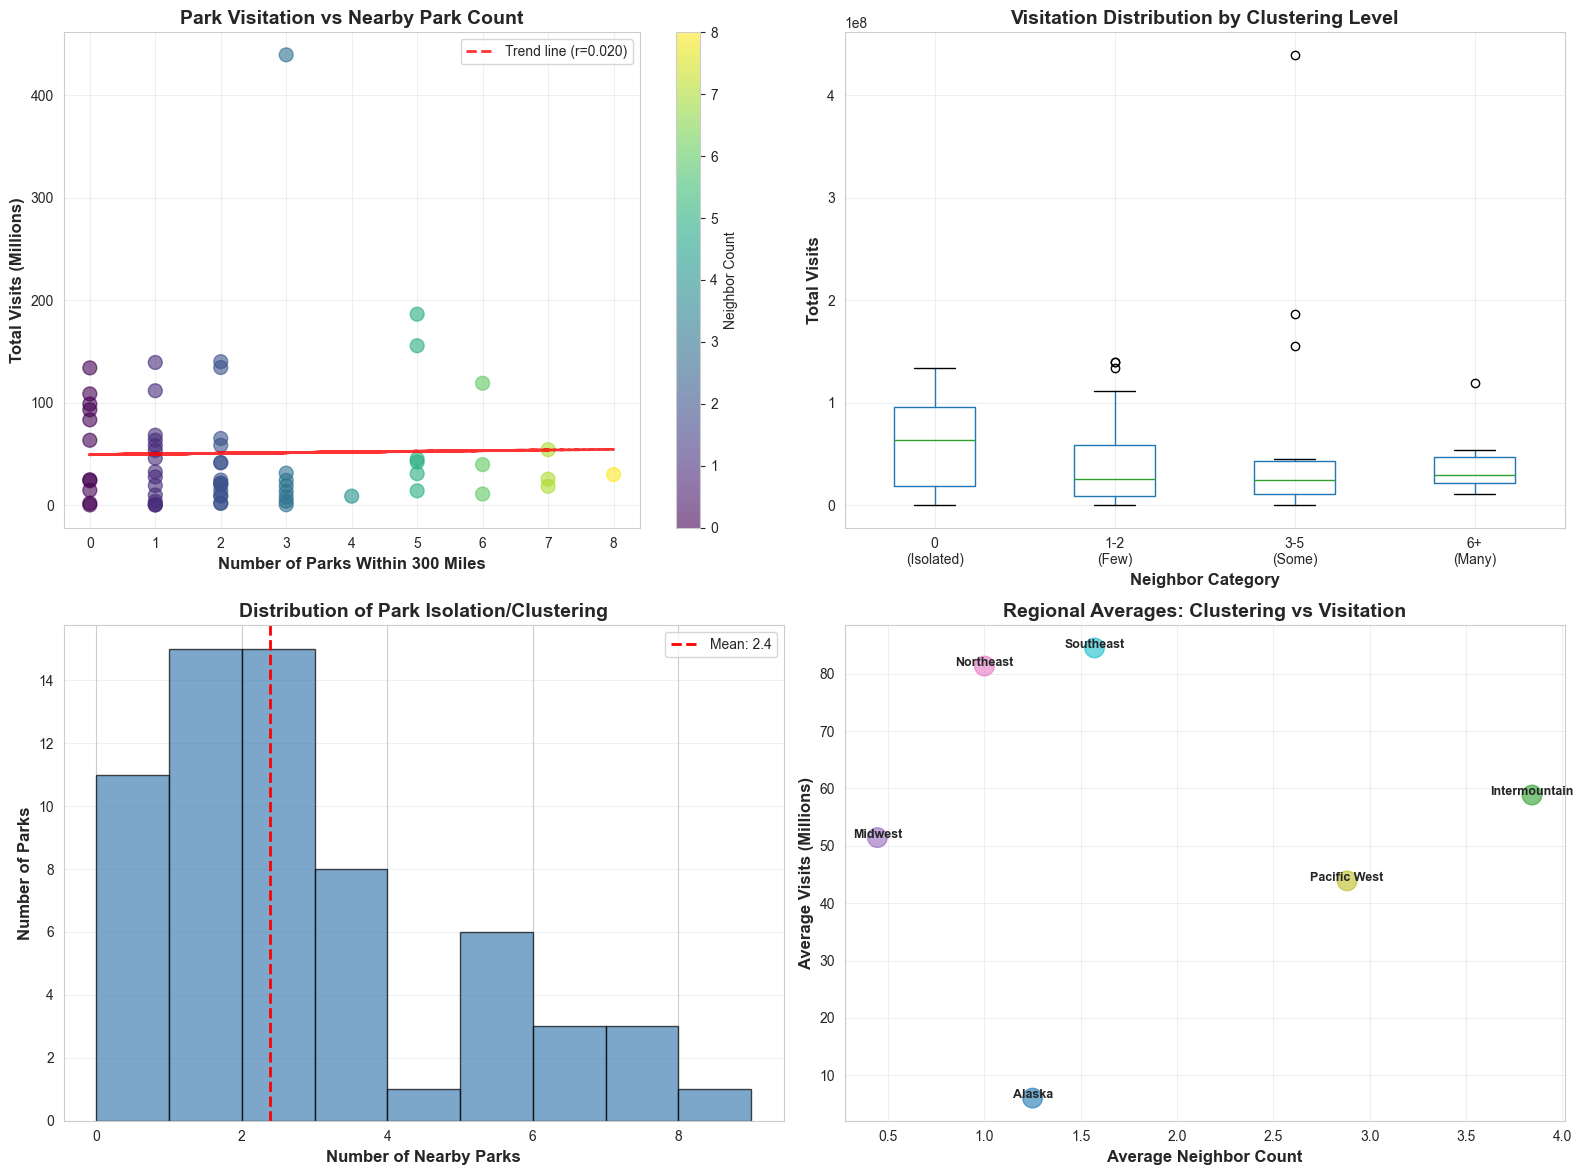

In [64]:
# Main visualization: 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. MAIN SCATTERPLOT: Neighbor Count vs Visits
ax1 = axes[0, 0]
scatter = ax1.scatter(neighbor_df['Neighbor Count'], 
                      neighbor_df['Total Visits'] / 1e6,
                      alpha=0.6, s=100, c=neighbor_df['Neighbor Count'], 
                      cmap='viridis')
ax1.set_xlabel(f'Number of Parks Within {RADIUS_MILES} Miles', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Visits (Millions)', fontsize=12, fontweight='bold')
ax1.set_title('Park Visitation vs Nearby Park Count', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Neighbor Count')

# Add trend line
z = np.polyfit(neighbor_df['Neighbor Count'], neighbor_df['Total Visits'] / 1e6, 1)
p = np.poly1d(z)
ax1.plot(neighbor_df['Neighbor Count'], p(neighbor_df['Neighbor Count']), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend line (r={correlation:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. BOX PLOT: Visits by Neighbor Category
ax2 = axes[0, 1]
neighbor_df['Neighbor Category'] = pd.cut(
    neighbor_df['Neighbor Count'], 
    bins=[-0.5, 0.5, 2.5, 5.5, 100],
    labels=['0\n(Isolated)', '1-2\n(Few)', '3-5\n(Some)', '6+\n(Many)']
)
neighbor_df.boxplot(column='Total Visits', by='Neighbor Category', ax=ax2)
ax2.set_xlabel('Neighbor Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Visits', fontsize=12, fontweight='bold')
ax2.set_title('Visitation Distribution by Clustering Level', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
ax2.grid(True, alpha=0.3)

# 3. HISTOGRAM: Distribution of Neighbor Counts
ax3 = axes[1, 0]
ax3.hist(neighbor_df['Neighbor Count'], 
         bins=range(0, int(neighbor_df['Neighbor Count'].max())+2), 
         edgecolor='black', alpha=0.7, color='steelblue')
ax3.set_xlabel('Number of Nearby Parks', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Parks', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Park Isolation/Clustering', fontsize=14, fontweight='bold')
ax3.axvline(neighbor_df['Neighbor Count'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {neighbor_df["Neighbor Count"].mean():.1f}')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. REGIONAL COMPARISON
ax4 = axes[1, 1]
regional_avg = neighbor_df.groupby('Region').agg({
    'Neighbor Count': 'mean',
    'Total Visits': 'mean'
}).reset_index()

ax4.scatter(regional_avg['Neighbor Count'], regional_avg['Total Visits'] / 1e6, 
           s=200, alpha=0.6, c=range(len(regional_avg)), cmap='tab10')
for idx, row in regional_avg.iterrows():
    ax4.annotate(row['Region'], 
                (row['Neighbor Count'], row['Total Visits'] / 1e6),
                fontsize=9, ha='center', fontweight='bold')
ax4.set_xlabel('Average Neighbor Count', fontsize=12, fontweight='bold')
ax4.set_ylabel('Average Visits (Millions)', fontsize=12, fontweight='bold')
ax4.set_title('Regional Averages: Clustering vs Visitation', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('neighbor_count_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: neighbor_count_analysis.png")
plt.show()

## Save Results

In [65]:
# Save the full results table
neighbor_df_export = neighbor_df[[
    'Park Name', 'Region', 'Neighbor Count', 'Total Visits', 
    'Avg Distance to Neighbors', 'Closest 3 Neighbors'
]].sort_values('Neighbor Count', ascending=False)

neighbor_df_export.to_csv('neighbor_count_results.csv', index=False)
print("✓ Saved: neighbor_count_results.csv")

# Also save a summary for your report
summary_stats = pd.DataFrame({
    'Metric': [
        'Radius (miles)',
        'Total Parks Analyzed',
        'Average Neighbor Count',
        'Median Neighbor Count',
        'Parks with 0 Neighbors',
        'Parks with 6+ Neighbors',
        'Correlation (r)'
    ],
    'Value': [
        RADIUS_MILES,
        len(neighbor_df),
        f"{neighbor_df['Neighbor Count'].mean():.2f}",
        f"{neighbor_df['Neighbor Count'].median():.0f}",
        (neighbor_df['Neighbor Count'] == 0).sum(),
        (neighbor_df['Neighbor Count'] >= 6).sum(),
        f"{correlation:.3f}"
    ]
})

summary_stats.to_csv('neighbor_analysis_summary.csv', index=False)
print("✓ Saved: neighbor_analysis_summary.csv")
print("\n", summary_stats.to_string(index=False))

✓ Saved: neighbor_count_results.csv
✓ Saved: neighbor_analysis_summary.csv

                  Metric Value
         Radius (miles)   300
   Total Parks Analyzed    63
 Average Neighbor Count  2.38
  Median Neighbor Count     2
 Parks with 0 Neighbors    11
Parks with 6+ Neighbors     7
        Correlation (r) 0.020


---
# APPROACH 2: GRID-BASED ANALYSIS


Divide the US into equal-sized grid squares to avoid comparing regions with different park counts.

In [66]:
# Grid parameters
GRID_SIZE_MILES = 150
MIN_PARKS_PER_GRID = 2

print(f"Performing grid-based analysis...")
print(f"Grid size: {GRID_SIZE_MILES}x{GRID_SIZE_MILES} miles")
print(f"Minimum parks per grid: {MIN_PARKS_PER_GRID}\n")

# Convert miles to degrees (rough approximation: 1 degree ≈ 69 miles)
grid_size_degrees = GRID_SIZE_MILES / 69.0

# Create grid coordinates
lat_min, lat_max = parks_df['Latitude'].min(), parks_df['Latitude'].max()
lon_min, lon_max = parks_df['Longitude'].min(), parks_df['Longitude'].max()

# Assign each park to a grid cell
parks_grid = parks_df.copy()
parks_grid['grid_lat'] = ((parks_grid['Latitude'] - lat_min) / grid_size_degrees).astype(int)
parks_grid['grid_lon'] = ((parks_grid['Longitude'] - lon_min) / grid_size_degrees).astype(int)
parks_grid['grid_id'] = parks_grid['grid_lat'].astype(str) + '_' + parks_grid['grid_lon'].astype(str)

# Aggregate by grid
grid_stats = parks_grid.groupby('grid_id').agg({
    'ParkName': ['count', lambda x: ', '.join(x)],
    'RecreationVisits': 'sum',
    'Latitude': 'mean',
    'Longitude': 'mean'
}).reset_index()

grid_stats.columns = ['grid_id', 'park_count', 'park_names', 'total_visits', 'center_lat', 'center_lon']
grid_stats['avg_visits_per_park'] = grid_stats['total_visits'] / grid_stats['park_count']

# Filter to grids with minimum parks
grid_stats_filtered = grid_stats[grid_stats['park_count'] >= MIN_PARKS_PER_GRID].copy()

print(f"Total grid squares: {len(grid_stats)}")
print(f"Grid squares with {MIN_PARKS_PER_GRID}+ parks: {len(grid_stats_filtered)}")
print(f"Grid square with most parks: {grid_stats['park_count'].max()} parks")

if len(grid_stats_filtered) > 0:
    print("\nTop 5 grid squares by park concentration:")
    top_grids = grid_stats_filtered.nlargest(5, 'park_count')[[
        'grid_id', 'park_count', 'avg_visits_per_park', 'park_names'
    ]]
    print(top_grids.to_string(index=False))
    
    # Correlation
    grid_correlation = grid_stats_filtered['park_count'].corr(grid_stats_filtered['avg_visits_per_park'])
    print(f"\nCorrelation (park count vs avg visits per park in grid): {grid_correlation:.3f}")
else:
    print(f"\nNo grid squares have {MIN_PARKS_PER_GRID}+ parks.")
    print(f"   Try a larger grid size or lower threshold.")

Performing grid-based analysis...
Grid size: 150x150 miles
Minimum parks per grid: 2

Total grid squares: 54
Grid squares with 2+ parks: 7
Grid square with most parks: 3 parks

Top 5 grid squares by park concentration:
grid_id  park_count  avg_visits_per_park                                  park_names
  23_23           3         7.721094e+07    Kings Canyon NP, Sequoia NP, Yosemite NP
  23_26           3         1.199670e+08   Bryce Canyon NP, Grand Canyon NP, Zion NP
  18_41           2         3.125731e+07                  Biscayne NP, Everglades NP
  21_30           2         1.623971e+07 Carlsbad Caverns NP, Guadalupe Mountains NP
  24_27           2         2.422778e+07             Canyonlands NP, Capitol Reef NP

Correlation (park count vs avg visits per park in grid): 0.934


## Grid Visualizations

✓ Saved: grid_based_analysis.png


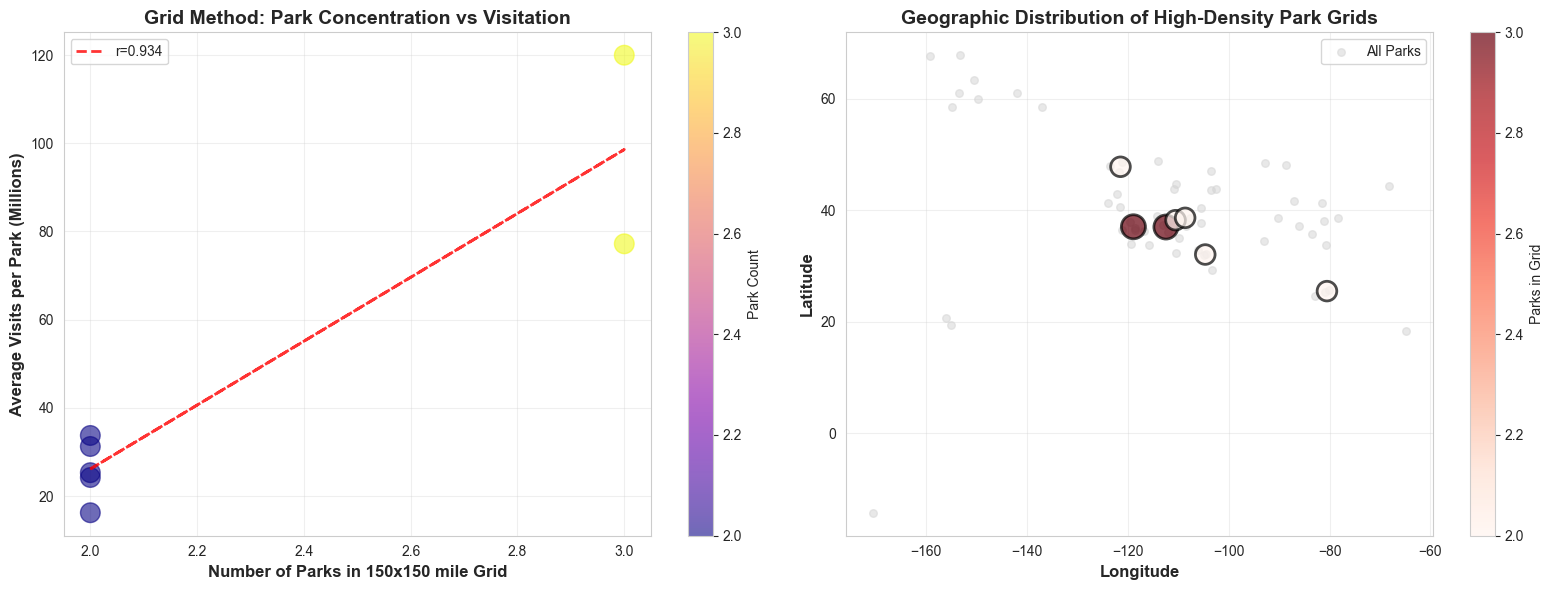

✓ Saved: grid_analysis_results.csv


In [67]:
if len(grid_stats_filtered) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Scatterplot: Park concentration vs average visits
    ax1 = axes[0]
    scatter = ax1.scatter(grid_stats_filtered['park_count'], 
                          grid_stats_filtered['avg_visits_per_park'] / 1e6,
                          s=200, alpha=0.6, c=grid_stats_filtered['park_count'],
                          cmap='plasma')
    ax1.set_xlabel(f'Number of Parks in {GRID_SIZE_MILES}x{GRID_SIZE_MILES} mile Grid', 
                   fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Visits per Park (Millions)', fontsize=12, fontweight='bold')
    ax1.set_title('Grid Method: Park Concentration vs Visitation', 
                  fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=ax1, label='Park Count')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(grid_stats_filtered['park_count'], 
                   grid_stats_filtered['avg_visits_per_park'] / 1e6, 1)
    p = np.poly1d(z)
    ax1.plot(grid_stats_filtered['park_count'], 
             p(grid_stats_filtered['park_count']), 
             "r--", alpha=0.8, linewidth=2, label=f'r={grid_correlation:.3f}')
    ax1.legend()
    
    # 2. Map view of grids
    ax2 = axes[1]
    # Plot all parks as background
    ax2.scatter(parks_df['Longitude'], parks_df['Latitude'], 
                c='lightgray', s=30, alpha=0.5, label='All Parks')
    # Highlight grid centers sized by park count
    scatter2 = ax2.scatter(grid_stats_filtered['center_lon'], 
                           grid_stats_filtered['center_lat'],
                           s=grid_stats_filtered['park_count']*100,
                           c=grid_stats_filtered['park_count'],
                           cmap='Reds', alpha=0.7, edgecolors='black', linewidth=2)
    ax2.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax2.set_title('Geographic Distribution of High-Density Park Grids', 
                  fontsize=14, fontweight='bold')
    ax2.legend()
    plt.colorbar(scatter2, ax=ax2, label='Parks in Grid')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('grid_based_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: grid_based_analysis.png")
    plt.show()
    
    # Save results
    grid_stats_filtered.to_csv('grid_analysis_results.csv', index=False)
    print("✓ Saved: grid_analysis_results.csv")
else:
    print("Cannot create visualizations - no grids meet the criteria.")

---
# APPROACH 3: METRO AREA ANALYSIS


In [68]:
METRO_RADIUS_MILES = 300

# Load metro areas from your CSV
metro_areas = pd.read_csv('/Users/rebeccayedid/Desktop/SI CLASSES/SI 699/mini project/usmetros.csv')

print(f"Analyzing parks within {METRO_RADIUS_MILES} miles of major metro areas...")
print(f"Loaded {len(metro_areas)} metro areas\n")

results = []

# Iterate through each metro area (using iterrows since it's a DataFrame)
for idx, metro_row in metro_areas.iterrows():
    parks_in_radius = []
    total_visits = 0
    
    # Check distance from this metro to each park
    for park_idx, park in parks_df.iterrows():
        distance = haversine(
            metro_row['lng'],      
            metro_row['lat'], 
            park['Longitude'], 
            park['Latitude']
        )
        
        if distance <= METRO_RADIUS_MILES:
            parks_in_radius.append(park['ParkName'])
            total_visits += park['RecreationVisits']
    
    # Only add metros that have parks within radius
    if len(parks_in_radius) > 0:
        results.append({
            'Metro Area': metro_row['metro'],           # Use 'metro' column for name
            'Metro FIPS': metro_row['metro_fips'],      # Include FIPS code
            'State': metro_row['state_id'],             # Include state
            'Population': metro_row['population'],       # Include population
            'Park Count': len(parks_in_radius),
            'Total Visits': total_visits,
            'Avg Visits per Park': total_visits / len(parks_in_radius),
            'Parks': ', '.join(parks_in_radius)
        })

if results:
    metro_df = pd.DataFrame(results).sort_values('Park Count', ascending=False)
    
    print(f"Found {len(metro_df)} metro areas with parks within {METRO_RADIUS_MILES} miles\n")
    print("="*80)
    print(f"Metro areas with parks within {METRO_RADIUS_MILES} miles:")
    print("="*80)
    print(metro_df[['Metro Area', 'State', 'Population', 'Park Count', 'Avg Visits per Park', 'Parks']].to_string(index=False))
    
    metro_correlation = metro_df['Park Count'].corr(metro_df['Avg Visits per Park'])
    print(f"\n🔑 Correlation (metro park count vs avg visits): {metro_correlation:.3f}")
    
    # BONUS: Check if metro population correlates with park visits
    pop_correlation = metro_df['Population'].corr(metro_df['Avg Visits per Park'])
    print(f"🔑 Correlation (metro population vs avg visits per park): {pop_correlation:.3f}")
    
    metro_df.to_csv('metro_analysis_results.csv', index=False)
    print("\n✓ Saved: metro_analysis_results.csv")
else:
    print("No parks found within radius of selected metro areas.")
    print("Try increasing METRO_RADIUS_MILES or check that your park data has correct coordinates.")

Analyzing parks within 300 miles of major metro areas...
Loaded 387 metro areas

Found 282 metro areas with parks within 300 miles

Metro areas with parks within 300 miles:
                     Metro Area State  Population  Park Count  Avg Visits per Park                                                                                                                                       Parks
                      Las Vegas    NV     2336573           8         6.838542e+07                     Bryce Canyon NP, Death Valley NP, Grand Canyon NP, Great Basin NP, Joshua Tree NP, Kings Canyon NP, Sequoia NP, Zion NP
                 St. George, UT    UT      202452           7         6.491315e+07                                 Bryce Canyon NP, Canyonlands NP, Capitol Reef NP, Death Valley NP, Grand Canyon NP, Great Basin NP, Zion NP
                  Flagstaff, AZ    AZ      144472           7         6.646447e+07                              Bryce Canyon NP, Canyonlands NP, Capitol Reef 

---
# Summary & Next Steps

In [69]:
print("="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

print("\n KEY FINDINGS TO REPORT:")
print(f"\n1. Neighbor Count Method:")
print(f"   - Correlation: r = {correlation:.3f}")
print(f"   - Average neighbors: {neighbor_df['Neighbor Count'].mean():.2f}")
print(f"   - Isolated parks: {(neighbor_df['Neighbor Count'] == 0).sum()}")

if len(grid_stats_filtered) > 0:
    print(f"\n2. Grid-Based Method:")
    print(f"   - Correlation: r = {grid_correlation:.3f}")
    print(f"   - Grid squares analyzed: {len(grid_stats_filtered)}")

if results:
    print(f"\n3. Metro Area Method:")
    print(f"   - Correlation: r = {metro_correlation:.3f}")
    print(f"   - Metro areas with parks: {len(metro_df)}")

print("\n" + "="*70)
print("NEXT STEPS FOR YOUR REPORT:")
print("="*70)
print("""
1. Use neighbor_count_analysis.png as your main figure
2. Report the correlation coefficient clearly
3. Show examples of clustered vs isolated parks
4. Interpret honestly - weak findings are OK!
5. Discuss why proximity might not be the main factor

FILES CREATED:
✓ neighbor_count_analysis.png (main figure)
✓ neighbor_count_results.csv (full data)
✓ neighbor_analysis_summary.csv (key stats)
""")

if len(grid_stats_filtered) > 0:
    print("✓ grid_based_analysis.png")
    print("✓ grid_analysis_results.csv")

if results:
    print("✓ metro_analysis_results.csv")

print("\n🎯 Remember: Use the REVISED_REPORT_TEMPLATE.md for writing!")

ANALYSIS COMPLETE!

 KEY FINDINGS TO REPORT:

1. Neighbor Count Method:
   - Correlation: r = 0.020
   - Average neighbors: 2.38
   - Isolated parks: 11

2. Grid-Based Method:
   - Correlation: r = 0.934
   - Grid squares analyzed: 7

3. Metro Area Method:
   - Correlation: r = -0.113
   - Metro areas with parks: 282

NEXT STEPS FOR YOUR REPORT:

1. Use neighbor_count_analysis.png as your main figure
2. Report the correlation coefficient clearly
3. Show examples of clustered vs isolated parks
4. Interpret honestly - weak findings are OK!
5. Discuss why proximity might not be the main factor

FILES CREATED:
✓ neighbor_count_analysis.png (main figure)
✓ neighbor_count_results.csv (full data)
✓ neighbor_analysis_summary.csv (key stats)

✓ grid_based_analysis.png
✓ grid_analysis_results.csv
✓ metro_analysis_results.csv

🎯 Remember: Use the REVISED_REPORT_TEMPLATE.md for writing!
